In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re
from torchvision.models import resnet18
import torch.nn as nn
from eqCLR.eq_resnet import EqResNet18, EqResNet
import pandas as pd
import escnn.nn as enn
from escnn.nn import EquivariantModule
from escnn import gspaces
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.transforms.functional as F
from evaluation import model_eval, eval_knn_single, dataset_to_X_y, lin_eval_rep
from medmnist import BloodMNIST
from torchvision.transforms import InterpolationMode
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

I0000 00:00:1779977364.209466 1572616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779977376.612039 1572616 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779977420.522243 1572616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
PROJECTOR_HIDDEN_SIZE = 1024
PROJECTOR_OUTPUT_SIZE = 128

In [4]:
###################### NETWORK ARCHITECTURE #########################
class ResNetwithProjector(nn.Module):
    def __init__(self, backbone_network, maxpool=True):
        super().__init__()
        self.backbone = backbone_network(weights=None)
        self.backbone_output_dim = self.backbone.fc.in_features
        if not maxpool:
            self.backbone.conv1 = nn.Conv2d(
                3, 64, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.maxpool = nn.Identity()
            
        self.backbone.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(self.backbone_output_dim, PROJECTOR_HIDDEN_SIZE), 
            nn.ReLU(), 
            nn.Linear(PROJECTOR_HIDDEN_SIZE, PROJECTOR_OUTPUT_SIZE),
        )
    def forward(self, x):
        h = self.backbone(x)
        z = self.projector(h)
        return h, z
            
    def infoNCE(features, temperature=0.5):
        x = F.normalize(features)
        cos_xx = x @ x.T / temperature
        cos_xx.fill_diagonal_(float("-inf"))
        
        batch_size = cos_xx.size(0) // 2
        targets = torch.arange(batch_size * 2, dtype=int, device=cos_xx.device)
        targets[:batch_size] += batch_size
        targets[batch_size:] -= batch_size
        return F.cross_entropy(cos_xx, targets)
        
simclr = ResNetwithProjector(resnet18)

In [5]:
eqCLR_n4 = EqResNet18(N=4, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [6]:
eqCLR_n4_nr = EqResNet18(N=4, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [6]:
mixed_eqCLR_n4 = EqResNet(N=4, eq_blocks=2, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

Make equivariant layer
Make equivariant layer
Make non-equivariant layer
Make non-equivariant layer
Hidden dim before projection head: 512


# Equivariance per layer

It must hold:
\begin{align}
f(Rx) = R(f(x))
\end{align}

Here we test this equivariance-property for rotations per layer

In [7]:
def in_shapes_layer_enn(model, input_size, device=None):
    """
    Returns a dictionary with input/output shapes per escnn layer.

    Parameters
    ----------
    model : enn.EquivariantModule
    input_size : tuple (N, C, H, W)
    device : torch.device

    Returns
    -------
    dict:
        {
            layer_name: {
                "in_shape": tuple,
                "out_shape": tuple,
                "in_type": escnn type,
                "out_type": escnn type (if available)
            }
        }
    """

    if device is None:
        device = next(model.parameters()).device

    shapes = {}
    handles = []

    def make_hook(name):
        def hook(module, inp, out):

            x_in = inp[0]
            x_out = out

            # escnn GeometricTensor
            if hasattr(x_in, "tensor") and hasattr(x_out, "tensor"):

                shapes[name] = {
                    "in_shape": x_in.tensor.shape,
                    "out_shape": x_out.tensor.shape,
                    "in_type": getattr(module, "in_type", None),
                    "out_type": getattr(module, "out_type", None)
                }

        return hook

    # register hooks only on escnn layers of interest
    for name, module in model.named_modules():

        if name == "":
            continue

        if isinstance(module, (enn.R2Conv, enn.PointwiseMaxPool2D)):

            handles.append(
                module.register_forward_hook(make_hook(name))
            )

    # build input
    x = torch.randn(*input_size, device=device)
    # x = enn.GeometricTensor(x, model.in_type)

    model.eval()

    with torch.no_grad():
        _ = model(x)

    for h in handles:
        h.remove()

    return shapes

In [ ]:
import torch
import numpy as np


def check_equivariance_escnn_group(
    self,
    module_info,
    atol=1e-7,
    rtol=1e-5
):

    device = next(self.parameters()).device
    errors = {}

    for name, module in self.named_modules():

        if name == "":
            continue

        if name not in module_info:
            continue

        info = module_info[name]

        # only escnn spatial modules
        if "in_shape" not in info:
            continue

        if len(info["in_shape"]) != 4:
            continue

        _, C, H, W = info["in_shape"]

        layer_errors = {}

        # =====================================================
        # rotation loop (same as CNN version)
        # =====================================================
        group_elements = self.in_type.gspace.fibergroup.elements
        
        x = torch.randn(1, C, H, W, device=device)
        x = enn.GeometricTensor(x, info["in_type"])

        for g in group_elements:

            out1 = module(x).transform(g).tensor.detach().cpu().numpy()
            out2 = module(x.transform(g)).tensor.detach().cpu().numpy()

            errs = np.abs(out1 - out2).reshape(-1)

            layer_errors[g] = errs.mean()

        errors[name] = layer_errors

    return errors


# attach
import escnn.nn as enn
enn.EquivariantModule.check_equivariance_escnn_group = check_equivariance_escnn_group

## Results

In [9]:
in_shapes_enn1 = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 128, 128))
eq_errors_eqCLR1 = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn1)

in_shapes_enn2 = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 128, 128))
eq_errors_eqCLR2 = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn2)

in_shapes_enn3 = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 128, 128))
eq_errors_eqCLR3 = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn3)

In [10]:
in_shapes_enn1_rs = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 129, 129))
eq_errors_eqCLR1_rs = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn1_rs)

in_shapes_enn2_rs = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 129, 129))
eq_errors_eqCLR2_rs = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn2_rs)

in_shapes_enn3_rs = in_shapes_layer_enn(eqCLR_n4, input_size=(1, 3, 129, 129))
eq_errors_eqCLR3_rs = check_equivariance_escnn_group(eqCLR_n4, in_shapes_enn3_rs)

In [11]:
dicts = [eq_errors_eqCLR1, eq_errors_eqCLR2, eq_errors_eqCLR3]

# get all layer names
layers = dicts[0].keys()

# build mean/std dictionary
mean_dict = {}
std_dict = {}

for layer in layers:

    # get all rotation keys for this layer
    rot_keys = dicts[0][layer].keys()

    mean_dict[layer] = {}
    std_dict[layer] = {}

    for rot in rot_keys:

        values = [d[layer][rot] for d in dicts]

        mean_dict[layer][f"{rot}"] = np.mean(values)
        std_dict[layer][f"{rot}"]  = np.std(values)

# convert to dataframe
eq_errors_mean_eqCLR_df = pd.DataFrame.from_dict(mean_dict, orient='index')
eq_errors_mean_eqCLR_df['mean_error'] = eq_errors_mean_eqCLR_df.mean(axis=1)
display(eq_errors_mean_eqCLR_df)

eq_errors_std_eqCLR_df = pd.DataFrame.from_dict(std_dict, orient='index')
eq_errors_std_eqCLR_df['std_error'] = eq_errors_std_eqCLR_df.mean(axis=1)
display(eq_errors_std_eqCLR_df)

,0[2pi/4],1[2pi/4],2[2pi/4],3[2pi/4],mean_error
conv1,0.0,8.266828e-01,9.772008e-01,8.253555e-01,6.573098e-01
maxpool,0.0,2.842164e-01,4.340199e-01,2.845430e-01,2.506948e-01
layer1.0.conv1,0.0,2.773494e-07,2.883336e-07,2.772433e-07,2.107316e-07
layer1.0.conv2,0.0,2.760952e-07,2.864999e-07,2.765070e-07,2.097755e-07
layer1.1.conv1,0.0,2.752160e-07,2.862369e-07,2.754938e-07,2.092366e-07
layer1.1.conv2,0.0,2.768658e-07,2.888202e-07,2.763639e-07,2.105125e-07
layer2.0.conv1,0.0,1.074527e+00,1.113656e+00,1.075699e+00,8.159707e-01
layer2.0.conv2,0.0,2.722070e-07,2.829615e-07,2.727569e-07,2.069813e-07
layer2.0.downsample.0,0.0,1.135725e+00,1.133434e+00,1.130207e+00,8.498416e-01
layer2.1.conv1,0.0,2.728113e-07,2.835212e-07,2.720054e-07,2.070845e-07


,0[2pi/4],1[2pi/4],2[2pi/4],3[2pi/4],std_error
conv1,0.0,2.558541e-03,3.987464e-04,7.946988e-04,9.379966e-04
maxpool,0.0,1.219915e-03,1.437292e-03,1.259546e-03,9.791881e-04
layer1.0.conv1,0.0,3.535518e-10,1.301757e-09,7.333448e-10,5.971633e-10
layer1.0.conv2,0.0,8.158357e-10,1.185608e-09,1.006306e-09,7.519375e-10
layer1.1.conv1,0.0,3.480632e-10,7.048557e-10,1.131854e-09,5.461931e-10
layer1.1.conv2,0.0,6.289718e-10,1.046685e-09,6.950054e-10,5.926655e-10
layer2.0.conv1,0.0,6.743587e-03,6.669226e-03,3.708384e-03,4.280299e-03
layer2.0.conv2,0.0,1.213517e-09,1.080525e-09,4.191076e-10,6.782874e-10
layer2.0.downsample.0,0.0,7.041214e-03,1.832999e-03,2.123750e-03,2.749491e-03
layer2.1.conv1,0.0,4.536780e-10,5.099976e-10,4.642328e-10,3.569771e-10


In [12]:
dicts = [eq_errors_eqCLR1_rs, eq_errors_eqCLR2_rs, eq_errors_eqCLR3_rs]

# get all layer names
layers = dicts[0].keys()

# build mean/std dictionary
mean_dict = {}
std_dict = {}

for layer in layers:

    # get all rotation keys for this layer
    rot_keys = dicts[0][layer].keys()

    mean_dict[layer] = {}
    std_dict[layer] = {}

    for rot in rot_keys:

        values = [d[layer][rot] for d in dicts]

        mean_dict[layer][f"{rot}"] = np.mean(values)
        std_dict[layer][f"{rot}"]  = np.std(values)

# convert to dataframe
eq_errors_mean_eqCLR_rs_df = pd.DataFrame.from_dict(mean_dict, orient='index')
eq_errors_mean_eqCLR_rs_df['mean_error'] = eq_errors_mean_eqCLR_rs_df.mean(axis=1)
display(eq_errors_mean_eqCLR_rs_df)

eq_errors_std_eqCLR_rs_df = pd.DataFrame.from_dict(std_dict, orient='index')
eq_errors_std_eqCLR_rs_df['std_error'] = eq_errors_std_eqCLR_rs_df.mean(axis=1)
display(eq_errors_std_eqCLR_rs_df)

,0[2pi/4],1[2pi/4],2[2pi/4],3[2pi/4],mean_error
conv1,0.0,2.658893e-07,2.703243e-07,2.661361e-07,2.005874e-07
maxpool,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
layer1.0.conv1,0.0,2.773308e-07,2.890362e-07,2.773437e-07,2.109277e-07
layer1.0.conv2,0.0,2.754700e-07,2.869734e-07,2.757345e-07,2.095445e-07
layer1.1.conv1,0.0,2.752712e-07,2.874313e-07,2.760287e-07,2.096828e-07
layer1.1.conv2,0.0,2.764563e-07,2.883667e-07,2.766059e-07,2.103572e-07
layer2.0.conv1,0.0,2.668168e-07,2.784892e-07,2.671760e-07,2.031205e-07
layer2.0.conv2,0.0,2.749256e-07,2.847087e-07,2.754132e-07,2.087619e-07
layer2.0.downsample.0,0.0,7.017982e-08,7.429171e-08,7.012904e-08,5.365014e-08
layer2.1.conv1,0.0,2.742890e-07,2.852300e-07,2.745105e-07,2.085074e-07


,0[2pi/4],1[2pi/4],2[2pi/4],3[2pi/4],std_error
conv1,0.0,8.197997e-10,7.827060e-10,6.347429e-10,5.593122e-10
maxpool,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
layer1.0.conv1,0.0,6.411476e-10,6.744161e-10,1.175625e-09,6.227971e-10
layer1.0.conv2,0.0,7.784514e-10,3.913917e-10,3.767188e-10,3.866405e-10
layer1.1.conv1,0.0,5.749586e-10,7.739035e-10,4.171729e-10,4.415087e-10
layer1.1.conv2,0.0,6.029460e-10,8.561248e-10,5.297982e-10,4.972173e-10
layer2.0.conv1,0.0,8.096052e-10,1.278678e-09,1.370966e-09,8.648123e-10
layer2.0.conv2,0.0,4.007519e-10,1.782381e-09,5.211250e-10,6.760645e-10
layer2.0.downsample.0,0.0,4.417991e-10,6.163405e-10,4.670132e-10,3.812882e-10
layer2.1.conv1,0.0,8.105666e-10,1.273885e-09,7.176513e-10,7.005257e-10


In [13]:
from matplotlib.patches import PathPatch
from matplotlib.path import Path

def add_group_box(ax, x0, x1, y, h, text=None, lw=1, font=12):
    """
    Draw an open rectangle/bracket from x0 to x1.

    Parameters
    ----------
    x0, x1 : float
        Start/end x positions
    y : float
        Bottom y position
    h : float
        Height of bracket
    """

    verts = [
        (x0, y+h),   # left top
        (x0, y),     # left bottom
        (x1, y),     # right bottom
        (x1, y+h),   # right top
    ]

    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.LINETO,
        Path.LINETO,
    ]

    path = Path(verts, codes)
    patch = PathPatch(path, fill=False, lw=lw, clip_on=False, color='black')
    ax.add_patch(patch)

    if text is not None:
        ax.text(
            (x0 + x1)/2,
            y - 0.02,
            text,
            ha='center',
            va='top',
            fontsize=font
        )

/tmp/ipykernel_788800/4221678984.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_label, rotation=90, fontsize=font)


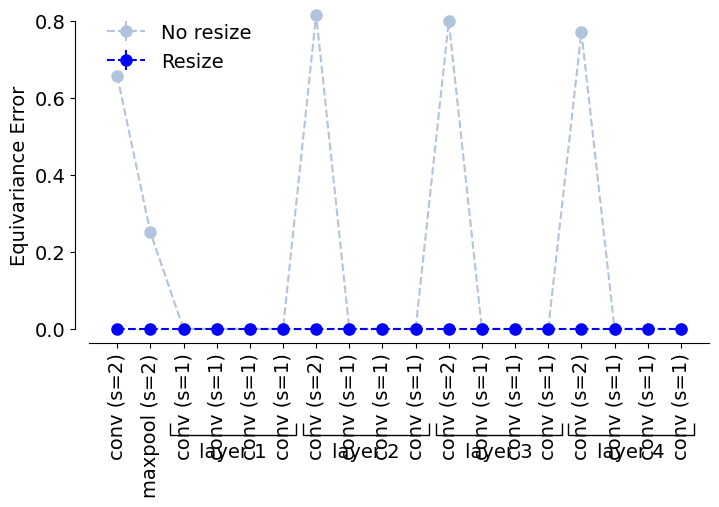

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

font = 14

x_label = ['conv (s=2)', 'maxpool (s=2)', 'conv (s=1)', 'conv (s=1)',
       'conv (s=1)', 'conv (s=1)', 'conv (s=2)', 'conv (s=1)',
       'conv (s=1)', 'conv (s=1)',
       'conv (s=2)', 'conv (s=1)', 
       'conv (s=1)', 'conv (s=1)', 'conv (s=2)', 'conv (s=1)',
        'conv (s=1)', 'conv (s=1)']

x = [idx for idx in eq_errors_mean_eqCLR_df.index if "downsample" not in idx]
y = [eq_errors_mean_eqCLR_df['mean_error'][idx] for idx in x]
y_rs = [eq_errors_mean_eqCLR_rs_df['mean_error'][idx] for idx in x]
std = [eq_errors_std_eqCLR_df['std_error'][idx] for idx in x]
std_rs = [eq_errors_std_eqCLR_rs_df['std_error'][idx] for idx in x]

ax.errorbar(x, y, yerr=std, fmt='--o', label='No resize', color='lightsteelblue', markersize=8, clip_on=False)
ax.errorbar(x, y_rs, yerr=std_rs, fmt='--o', label='Resize', color='blue', markersize=8, clip_on=False)

# ax.errorbar(x, eq_errors_mean_eqCLR_df['mean_error'], yerr=eq_errors_std_eqCLR_df['std_error'], fmt='--o', label='No resize', color='lightsteelblue')
# ax.errorbar(x, eq_errors_mean_eqCLR_rs_df['mean_error'], yerr=eq_errors_std_eqCLR_rs_df['std_error'], fmt='--o', label='Resize', color='blue')

ax.legend(frameon=False, fontsize=font, bbox_to_anchor=(0.0, 1.05), loc='upper left')
ax.set_ylabel('Equivariance Error', fontsize=font)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.set_xticklabels(x_label, rotation=90, fontsize=font)
ax.set_ylim(0, 0.8)
# ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.tick_params(axis='both', which='major', labelsize=font)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Example groups
#plt.subplots_adjust(bottom=-0.4)

# add_group_box(ax, -0.2, 1.2, y=-0.08, h=0.04, text='Stem')
offset = -0.275
add_group_box(ax, 1.6, 5.4, y=offset, h=0.03, text='layer 1', font=font)
add_group_box(ax, 5.6, 9.4, y=offset, h=0.03, text='layer 2', font=font)
add_group_box(ax, 9.6, 13.4, y=offset, h=0.03, text='layer 3', font=font)
add_group_box(ax, 13.6, 17.4, y=offset, h=0.03, text='layer 4', font=font)


# Prediction under test set rotation

In [7]:
eqCLR_weights = {
    rs: f'results_mlc/bloodmnist/model_weights/model_weights1000/0002_seed{rs}_bloodmnist_129-eqCLR_resnet18_N4_rot_kp_1000epochs_lr0.06_weights.pt' for rs in range(3)
}
mixed_eqCLR_weights = {
    rs: f'results_mlc/bloodmnist/model_weights/model_weights1000/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N4_rot_kp_1000epochs_weights.pt' for rs in range(3)
}
simclr_weights = {
    rs: f'results_mlc/bloodmnist/model_weights/model_weights1000/1001_seed{rs}_resnet18_bloodmnist_128_1000epochs_weights.pt' for rs in range(3)
}

In [9]:
#Rotated data with less artifacts
rot_data = {}

for shift in np.linspace(0, 1, 17):

    angle = shift * 360

    transform = transforms.Compose([

        transforms.Resize((129, 129)),

        # pad before rotation
        transforms.Pad(30, padding_mode='edge'),

        transforms.ToTensor(),

        # rotate
        transforms.Lambda(
            lambda img, a=angle: F.rotate(
                img,
                a,
                interpolation=InterpolationMode.BILINEAR
            )
        ),

        # crop back to original size
        transforms.CenterCrop((129, 129)),
    ])

    data = BloodMNIST(
        split='test',
        download=False,
        size=128,
        root='data/bloodmnist128/',
        transform=transform
    )

    rot_data[shift] = data

transform = transforms.Compose([
            transforms.Resize((129, 129)),
            transforms.ToTensor(),
        ])

blood_train = BloodMNIST(split='train', download=False, size=128, root='data/bloodmnist128/', transform=transform)
blood_test = BloodMNIST(split='test', download=False, size=128, root='data/bloodmnist128/', transform=transform)


In [10]:
# Rotated data (no resize)
rot_data_nr = {}

for shift in np.linspace(0, 1, 17):

    angle = shift * 360

    transform = transforms.Compose([

        # pad before rotation
        transforms.Pad(30, padding_mode='edge'),

        transforms.ToTensor(),

        # rotate
        transforms.Lambda(
            lambda img, a=angle: F.rotate(
                img,
                a,
                interpolation=InterpolationMode.BILINEAR
            )
        ),

        # crop back to original size
        transforms.CenterCrop((128, 128)),
    ])

    data = BloodMNIST(
        split='test',
        download=False,
        size=128,
        root='data/bloodmnist128/',
        transform=transform
    )

    rot_data_nr[shift] = data

transform = transforms.Compose([
            transforms.ToTensor(),
])

blood_train_nr = BloodMNIST(split='train', download=False, size=128, root='data/bloodmnist128/', transform=transform)
blood_test_nr = BloodMNIST(split='test', download=False, size=128, root='data/bloodmnist128/', transform=transform)


(0.0, 1.0, 0.0, 1.0)

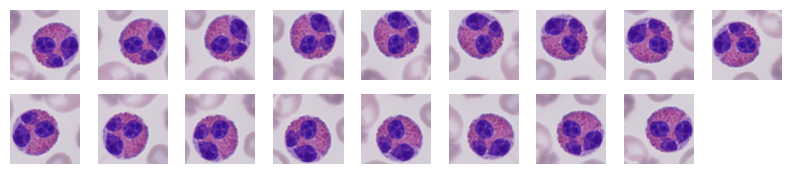

In [11]:
fig, ax = plt.subplots(2, 9, figsize=(10, 2))

ax = ax.flatten()
for i, rot in enumerate(rot_data.keys()):
    img, _ = rot_data[rot][4]  # get first image from dataset
    ax[i].imshow(img.numpy().transpose(1, 2, 0))
    ax[i].axis('off')

ax[-1].axis('off')

In [12]:
device = "cuda"
simclr.to(device)
eqCLR_n4.to(device)
mixed_eqCLR_n4.to(device)

simclr.eval()
eqCLR_n4.eval()
mixed_eqCLR_n4.eval()

EqResNet(
  (eq_stages): ModuleList(
    (0): R2Conv([C4_on_R2[(None, 4)]: {irrep_0 (x3)}(3)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=7, stride=2, padding=3)
    (1): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=False, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
    (3): PointwiseMaxPool2D()
    (4): SequentialModule(
      (0): EqBasicBlock(
        (conv1): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padding=1, bias=False)
        (bn1): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=False, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
        (conv2): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padd

In [13]:
eval_shifts = {}
eval_shifts['SimCLR'] = {}
eval_shifts['eqCLR_n4'] = {}
eval_shifts['mixed_eqCLR'] = {}

with torch.no_grad():
    for rs in range(3):
        print(f"Evaluating seed {rs}...")
        eval_shifts['SimCLR'][f'seed{rs}'] = {}
        eval_shifts['eqCLR_n4'][f'seed{rs}'] = {}
        eval_shifts['mixed_eqCLR'][f'seed{rs}'] = {}

        # Load weights
        simclr.load_state_dict(torch.load(simclr_weights[rs], weights_only=True))
        eqCLR_n4.load_state_dict(torch.load(eqCLR_weights[rs], weights_only=True))
        mixed_eqCLR_n4.load_state_dict(torch.load(mixed_eqCLR_weights[rs], weights_only=True))

        # SimCLR
        X_train_sim, y_train_sim, Z_train_sim = dataset_to_X_y(blood_train_nr, simclr)
        # eqCLR
        X_train_eq, y_train_eq, Z_train_eq = dataset_to_X_y(blood_train, eqCLR_n4)
        # # mixed_eqCLR
        X_train_mixed, y_train_mixed, Z_train_mixed = dataset_to_X_y(blood_train, mixed_eqCLR_n4)

        for rot in rot_data.keys():
            print(f"Evaluating rotation {rot}...")

            # Test data
            X_test_sim, y_test_sim, Z_test_sim = dataset_to_X_y(rot_data_nr[rot], simclr)
            X_test_eq, y_test_eq, Z_test_eq = dataset_to_X_y(rot_data[rot], eqCLR_n4)
            X_test_mixed, y_test_mixed, Z_test_mixed = dataset_to_X_y(rot_data[rot], mixed_eqCLR_n4)

            # KNN
            knn_sim = eval_knn_single(X_train_sim, y_train_sim, X_test_sim, y_test_sim)
            knn_eq = eval_knn_single(X_train_eq, y_train_eq, X_test_eq, y_test_eq)
            knn_mixed = eval_knn_single(X_train_mixed, y_train_mixed, X_test_mixed, y_test_mixed)

            # with torch.enable_grad():
            #     knn_sim = lin_eval_rep(X_train_sim, y_train_sim, X_test_sim, y_test_sim, 8)
            #     knn_eq = lin_eval_rep(X_train_eq, y_train_eq, X_test_eq, y_test_eq, 8)
            #     knn_eq_n8 = lin_eval_rep(X_train_eq_n8, y_train_eq_n8, X_test_eq_n8, y_test_eq_n8, 8)
            #     knn_mixed = lin_eval_rep(X_train_mixed, y_train_mixed, X_test_mixed, y_test_mixed, 8)

            eval_shifts['SimCLR'][f'seed{rs}'][rot] = knn_sim
            eval_shifts['eqCLR_n4'][f'seed{rs}'][rot] = knn_eq
            eval_shifts['mixed_eqCLR'][f'seed{rs}'][rot] = knn_mixed


Evaluating seed 0...
Evaluating rotation 0.0...
Evaluating rotation 0.0625...
Evaluating rotation 0.125...
Evaluating rotation 0.1875...
Evaluating rotation 0.25...
Evaluating rotation 0.3125...
Evaluating rotation 0.375...
Evaluating rotation 0.4375...
Evaluating rotation 0.5...
Evaluating rotation 0.5625...
Evaluating rotation 0.625...
Evaluating rotation 0.6875...
Evaluating rotation 0.75...
Evaluating rotation 0.8125...
Evaluating rotation 0.875...
Evaluating rotation 0.9375...
Evaluating rotation 1.0...
Evaluating seed 1...
Evaluating rotation 0.0...
Evaluating rotation 0.0625...
Evaluating rotation 0.125...
Evaluating rotation 0.1875...
Evaluating rotation 0.25...
Evaluating rotation 0.3125...
Evaluating rotation 0.375...
Evaluating rotation 0.4375...
Evaluating rotation 0.5...
Evaluating rotation 0.5625...
Evaluating rotation 0.625...
Evaluating rotation 0.6875...
Evaluating rotation 0.75...
Evaluating rotation 0.8125...
Evaluating rotation 0.875...
Evaluating rotation 0.9375...

In [14]:
simclr_df = pd.DataFrame(eval_shifts['SimCLR']).T
display(simclr_df)

simclr_mean = simclr_df.mean()
simclr_std = simclr_df.std()
print("SimCLR KNN mean:", simclr_mean)
print("SimCLR KNN std:", simclr_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.983631,0.981877,0.979538,0.982461,0.986261,0.984215,0.983338,0.983923,0.985092,0.982169,0.983338,0.984215,0.983923,0.982754,0.983338,0.982754,0.983631
seed1,0.984215,0.983046,0.982754,0.983338,0.985677,0.985092,0.983631,0.983046,0.986261,0.984800,0.982754,0.985092,0.986261,0.983631,0.982754,0.983631,0.984215
seed2,0.985677,0.983631,0.984507,0.986261,0.987138,0.985677,0.984507,0.985969,0.986846,0.986554,0.984215,0.984215,0.985969,0.985092,0.986261,0.985092,0.985677


SimCLR KNN mean: 0.0000    0.984507
0.0625    0.982851
0.1250    0.982266
0.1875    0.984020
0.2500    0.986359
0.3125    0.984995
0.3750    0.983825
0.4375    0.984313
0.5000    0.986066
0.5625    0.984507
0.6250    0.983436
0.6875    0.984507
0.7500    0.985384
0.8125    0.983825
0.8750    0.984118
0.9375    0.983825
1.0000    0.984507
dtype: float64
SimCLR KNN std: 0.0000    0.001054
0.0625    0.000893
0.1250    0.002520
0.1875    0.001990
0.2500    0.000736
0.3125    0.000736
0.3750    0.000608
0.4375    0.001500
0.5000    0.000893
0.5625    0.002207
0.6250    0.000736
0.6875    0.000506
0.7500    0.001274
0.8125    0.001181
0.8750    0.001879
0.9375    0.001181
1.0000    0.001054
dtype: float64


In [15]:
eq_n4_df = pd.DataFrame(eval_shifts['eqCLR_n4']).T
display(eq_n4_df)

eq_n4_mean = eq_n4_df.mean()
eq_n4_std = eq_n4_df.std()
print("eqCLR N4 KNN mean:", eq_n4_mean)
print("eqCLR N4 KNN std:", eq_n4_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.983923,0.983631,0.981877,0.983631,0.983923,0.983631,0.981877,0.983631,0.983923,0.983631,0.981877,0.983631,0.983923,0.983631,0.981877,0.983631,0.983923
seed1,0.986554,0.985969,0.985092,0.986554,0.986554,0.985969,0.985092,0.986554,0.986554,0.985969,0.985092,0.986554,0.986554,0.985969,0.985092,0.986554,0.986554
seed2,0.986261,0.986261,0.984800,0.985092,0.986261,0.986261,0.984800,0.985092,0.986261,0.986261,0.984800,0.985092,0.986261,0.986261,0.984800,0.985092,0.986261


eqCLR N4 KNN mean: 0.0000    0.985579
0.0625    0.985287
0.1250    0.983923
0.1875    0.985092
0.2500    0.985579
0.3125    0.985287
0.3750    0.983923
0.4375    0.985092
0.5000    0.985579
0.5625    0.985287
0.6250    0.983923
0.6875    0.985092
0.7500    0.985579
0.8125    0.985287
0.8750    0.983923
0.9375    0.985092
1.0000    0.985579
dtype: float64
eqCLR N4 KNN std: 0.0000    0.001442
0.0625    0.001442
0.1250    0.001778
0.1875    0.001462
0.2500    0.001442
0.3125    0.001442
0.3750    0.001778
0.4375    0.001462
0.5000    0.001442
0.5625    0.001442
0.6250    0.001778
0.6875    0.001462
0.7500    0.001442
0.8125    0.001442
0.8750    0.001778
0.9375    0.001462
1.0000    0.001442
dtype: float64


In [16]:
mixed_df = pd.DataFrame(eval_shifts['mixed_eqCLR']).T
display(mixed_df)

mixed_mean = mixed_df.mean()
mixed_std = mixed_df.std()
print("mixed_eqCLR KNN mean:", mixed_mean)
print("mixed_eqCLR KNN std:", mixed_std)

,0.0000,0.0625,0.1250,0.1875,0.2500,0.3125,0.3750,0.4375,0.5000,0.5625,0.6250,0.6875,0.7500,0.8125,0.8750,0.9375,1.0000
seed0,0.981292,0.980707,0.980123,0.980123,0.980707,0.977784,0.978661,0.979538,0.979830,0.981584,0.979538,0.980415,0.980707,0.980415,0.980123,0.981000,0.981292
seed1,0.981877,0.980415,0.981000,0.980415,0.979830,0.978661,0.978077,0.976907,0.980707,0.977784,0.977200,0.976615,0.978077,0.978954,0.978077,0.979830,0.981877
seed2,0.982461,0.980415,0.981877,0.981000,0.981584,0.979538,0.981877,0.981584,0.982754,0.980123,0.980415,0.981000,0.981292,0.980415,0.981877,0.981877,0.982461


mixed_eqCLR KNN mean: 0.0000    0.981877
0.0625    0.980513
0.1250    0.981000
0.1875    0.980513
0.2500    0.980707
0.3125    0.978661
0.3750    0.979538
0.4375    0.979343
0.5000    0.981097
0.5625    0.979830
0.6250    0.979051
0.6875    0.979343
0.7500    0.980025
0.8125    0.979928
0.8750    0.980025
0.9375    0.980902
1.0000    0.981877
dtype: float64
mixed_eqCLR KNN std: 0.0000    0.000585
0.0625    0.000169
0.1250    0.000877
0.1875    0.000447
0.2500    0.000877
0.3125    0.000877
0.3750    0.002046
0.4375    0.002345
0.5000    0.001500
0.5625    0.001917
0.6250    0.001662
0.6875    0.002381
0.7500    0.001713
0.8125    0.000844
0.8750    0.001902
0.9375    0.001027
1.0000    0.000585
dtype: float64


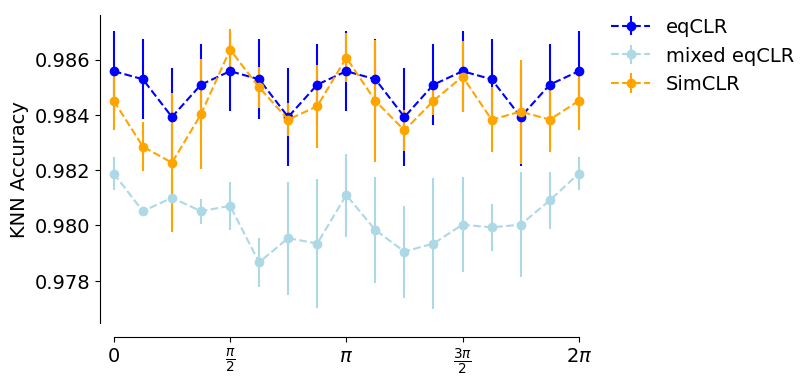

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
font_size = 14
ax.tick_params(axis='both', which='major', labelsize=font_size)

ax.errorbar(eq_n4_mean.index, eq_n4_mean.values, yerr=eq_n4_std.values, label='eqCLR', fmt='--o', clip_on=False, color='blue')
ax.errorbar(mixed_mean.index, mixed_mean.values, yerr=mixed_std.values, label='mixed eqCLR', fmt='--o', clip_on=False, color='lightblue')
ax.errorbar(simclr_mean.index, simclr_mean.values, yerr=simclr_std.values, label='SimCLR', fmt='--o', clip_on=False, color='orange')

ax.set_ylabel('KNN Accuracy', fontsize=font_size)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels([
    '0',
    r'$\frac{\pi}{2}$',
    r'$\pi$',
    r'$\frac{3\pi}{2}$',
    r'$2\pi$'
])
# ax.set_ylim(0.8, 0.9)
# ax.set_yticks([0.8, 0.82, 0.84, 0.86, 0.88, 0.9])

ax.legend(fontsize=font_size, frameon=False, loc='upper right', bbox_to_anchor=(1.5, 1.05))

# plt.savefig('figures/rot_equivariance.svg', bbox_inches='tight')

# Same class prediction

In [19]:
from rotation_eval import pred_consistency_90deg

In [ ]:
eqCLR_weights = {
    rs: f'results_mlc/bloodmnist/model_weights/C-0001_seed{rs}_bloodmnist_33-eqCLR_resnet18_N4_rot_kp_100epochs_b512_weights.pt' for rs in range(3)
}
simclr_weights_nr = {
    rs: f'results_mlc/bloodmnist/model_weights/1005_seed{rs}_resnet18_bloodmnist_no_resize_100epochs_weights.pt' for rs in range(3)
}
eqCLR_weights_nr = {
    rs: f'results_mlc/bloodmnist/model_weights/0005_seed{rs}_bloodmnist_no_resize-eqCLR_resnet18_N4_rot_kp_100epochs_b512_weights.pt' for rs in range(3)
}

In [ ]:
eqclr_nr = EqResNet18(N=4, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

In [ ]:
pred_const = {
    'SimCLR': {},
    'eqCLR_n4': {},
    'eqCLR_n4_nr': {}
}

for rs in range(3):
    eqCLR_n4.load_state_dict(torch.load(eqCLR_weights[rs], weights_only=True))
    eqCLR_n4_pred_consistency = pred_consistency_90deg(eqCLR_n4, blood_train, blood_test, 8)
    pred_const['eqCLR_n4'][f'seed{rs}'] = eqCLR_n4_pred_consistency

    if rs > 0:
        eqCLR_n4_nr.load_state_dict(torch.load(eqCLR_weights_nr[rs], weights_only=True))
        eqCLR_n4_nr_pred_consistency = pred_consistency_90deg(eqCLR_n4_nr, blood_train_nr, blood_test_nr, 8)
        pred_const['eqCLR_n4_nr'][f'seed{rs}'] = eqCLR_n4_nr_pred_consistency

    simclr.load_state_dict(torch.load(simclr_weights_nr[rs], weights_only=True))
    simclr_pred_consistency = pred_consistency_90deg(simclr, blood_train_nr, blood_test_nr, 8)
    pred_const['SimCLR'][f'seed{rs}'] = simclr_pred_consistency

Linear accuracy (Adam on precomputed representations): 0.8971061093247589
total_samples: 3421
all_same: 100.00%
1 different: 0.00%
2 different: 0.00%
all different: 0.00%
Linear accuracy (Adam on precomputed representations): 0.8456591639871383
total_samples: 3421
all_same: 86.09%
1 different: 12.95%
2 different: 0.96%
all different: 0.00%
Linear accuracy (Adam on precomputed representations): 0.8930137386729027
total_samples: 3421
all_same: 100.00%
1 different: 0.00%
2 different: 0.00%
all different: 0.00%
Linear accuracy (Adam on precomputed representations): 0.8760596316866414
total_samples: 3421
all_same: 87.96%
1 different: 11.25%
2 different: 0.79%
all different: 0.00%
Linear accuracy (Adam on precomputed representations): 0.84536685179772
total_samples: 3421
all_same: 85.15%
1 different: 13.94%
2 different: 0.91%
all different: 0.00%
Linear accuracy (Adam on precomputed representations): 0.893306050862321
total_samples: 3421
all_same: 99.97%
1 different: 0.03%
2 different: 0.00%

In [24]:
mean_results = {}

for model_name, seeds in pred_const.items():
    categories = seeds[next(iter(seeds))].keys()

    mean_results[model_name] = {
        category: np.mean([
            seed_data[category]
            for seed_data in seeds.values()
        ])
        for category in categories
    }

print(mean_results)

{'SimCLR': {'all_same': 85.58900906167787, '1 different': 13.44636071324174, '2 different': 0.9548864854331093, 'all different': 0.009743739647276624}, 'eqCLR_n4': {'all_same': 99.99025626035272, '1 different': 0.009743739647276624, '2 different': 0.0, 'all different': 0.0}, 'eqCLR_n4_nr': {'all_same': 88.20520315697165, '1 different': 11.064016369482609, '2 different': 0.7161648640748319, 'all different': 0.014615609470914937}}


/tmp/ipykernel_788800/184017763.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(x_label, rotation=90, fontsize=font)


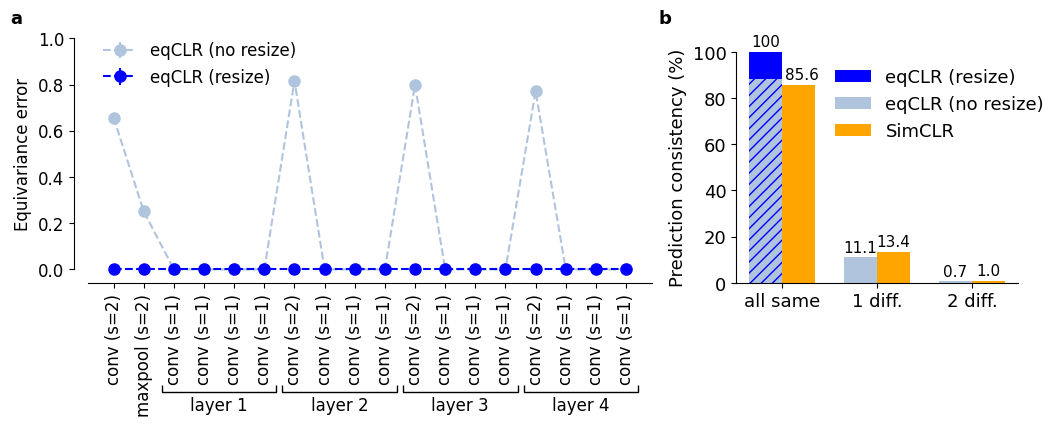

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'width_ratios': [1.5, 0.75]})

font = 12

x_label = ['conv (s=2)', 'maxpool (s=2)', 'conv (s=1)', 'conv (s=1)',
       'conv (s=1)', 'conv (s=1)', 'conv (s=2)', 'conv (s=1)',
       'conv (s=1)', 'conv (s=1)',
       'conv (s=2)', 'conv (s=1)', 
       'conv (s=1)', 'conv (s=1)', 'conv (s=2)', 'conv (s=1)',
        'conv (s=1)', 'conv (s=1)']

x = [idx for idx in eq_errors_mean_eqCLR_df.index if "downsample" not in idx]
y = [eq_errors_mean_eqCLR_df['mean_error'][idx] for idx in x]
y_rs = [eq_errors_mean_eqCLR_rs_df['mean_error'][idx] for idx in x]
std = [eq_errors_std_eqCLR_df['std_error'][idx] for idx in x]
std_rs = [eq_errors_std_eqCLR_rs_df['std_error'][idx] for idx in x]

ax[0].errorbar(x, y, yerr=std, fmt='--o', label='eqCLR (no resize)', color='lightsteelblue', markersize=8, clip_on=False)
ax[0].errorbar(x, y_rs, yerr=std_rs, fmt='--o', label='eqCLR (resize)', color='blue', markersize=8, clip_on=False)

# ax.errorbar(x, eq_errors_mean_eqCLR_df['mean_error'], yerr=eq_errors_std_eqCLR_df['std_error'], fmt='--o', label='No resize', color='lightsteelblue')
# ax.errorbar(x, eq_errors_mean_eqCLR_rs_df['mean_error'], yerr=eq_errors_std_eqCLR_rs_df['std_error'], fmt='--o', label='Resize', color='blue')

ax[0].legend(frameon=False, fontsize=font, bbox_to_anchor=(0.0, 1.05), loc='upper left')
ax[0].set_ylabel('Equivariance error', fontsize=font)
ax[0].spines['left'].set_position(('outward', 10))
ax[0].spines['bottom'].set_position(('outward', 10))
ax[0].set_xticklabels(x_label, rotation=90, fontsize=font)
ax[0].set_ylim(0, 1.0)
#ax[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax[0].tick_params(axis='both', which='major', labelsize=font)

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# Example groups
#plt.subplots_adjust(bottom=-0.4)

# add_group_box(ax, -0.2, 1.2, y=-0.08, h=0.04, text='Stem')
offset = -0.53
add_group_box(ax[0], 1.6, 5.4, y=offset, h=0.03, text='layer 1', font=font)
add_group_box(ax[0], 5.6, 9.4, y=offset, h=0.03, text='layer 2', font=font)
add_group_box(ax[0], 9.6, 13.4, y=offset, h=0.03, text='layer 3', font=font)
add_group_box(ax[0], 13.6, 17.4, y=offset, h=0.03, text='layer 4', font=font)

# plot b)
font = font+1
# values
keys = ['all_same', '1 different', '2 different']
eqclr_vals = [mean_results['eqCLR_n4'][c] for c in keys]
eqclr_vals_nr = [mean_results['eqCLR_n4_nr'][c] for c in keys]
simclr_vals = [mean_results['SimCLR'][c] for c in keys]

# x positions
x = np.arange(len(keys))
width = 0.35

ax[1].bar(x - width/2, eqclr_vals, width, label='eqCLR (resize)', color='blue')
ax[1].bar(x[0] - width/2, eqclr_vals_nr[0], width, color='lightsteelblue', hatch='///', edgecolor='blue', linewidth=0)
ax[1].bar(x[1:] - width/2, eqclr_vals_nr[1:], width, color='lightsteelblue', label='eqCLR (no resize)')
ax[1].bar(x + width/2, simclr_vals, width, label='SimCLR', color='orange')

# Annotate bars with values
ax[1].text(x[0] - width/2, eqclr_vals[0] + 1, f'{eqclr_vals[0]:.0f}', ha='center', va='bottom', fontsize=font-2)
ax[1].text(x[0]+ 0.03 + width/2, simclr_vals[0] + 1, f'{simclr_vals[0]:.1f}', ha='center', va='bottom', fontsize=font-2)

ax[1].text(x[1] - width/2, eqclr_vals_nr[1] + 1, f'{eqclr_vals_nr[1]:.1f}', ha='center', va='bottom', fontsize=font-2)
ax[1].text(x[1] + width/2, simclr_vals[1] + 1, f'{simclr_vals[1]:.1f}', ha='center', va='bottom', fontsize=font-2)

ax[1].text(x[2] + width/2, simclr_vals[2] + 1, f'{simclr_vals[2]:.1f}', ha='center', va='bottom', fontsize=font-2)
ax[1].text(x[2] - width/2, eqclr_vals_nr[2] + 1, f'{eqclr_vals_nr[2]:.1f}', ha='center', va='bottom', fontsize=font-2)


# labels and styling
ax[1].set_ylabel('Prediction consistency (%)', fontsize=font)
ax[1].set_xticks(x)
ax[1].set_xticklabels(['all same', '1 diff.', '2 diff.'])
ax[1].set_ylim(0, 100)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=font)


ax[1].legend(fontsize=font, frameon=False, loc='upper right', bbox_to_anchor=(1.15, 1.0))
pos0 = ax[0].get_position()
pos1 = ax[1].get_position()

# make bottoms equal
ax[1].set_position([pos1.x0, pos0.y0 - 0.045, pos1.width, pos1.height])

# add a) and b) labels
fig.text(0.06, 0.93, 'a', fontsize=font, fontweight='bold')
fig.text(0.6, 0.93, 'b', fontsize=font, fontweight='bold')

fig.savefig('figures/rot_equivariance.pdf', bbox_inches='tight')